## Collecte et préparation des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
fake_url = "https://raw.githubusercontent.com/davidamouzou/Fake_news/main/data/fake.csv"
true_url = "https://raw.githubusercontent.com/davidamouzou/Fake_news/main/data/real.csv"

In [16]:
fake_df = pd.read_csv(fake_url, delimiter=",")
fake_df.head()

,id,title,text,subject,date
0,1,"""Breaking: New Study Finds Coffee Extends Lif...","""Researchers claim drinking 5 cups daily adds...",politics,2024-01-15
1,2,"""Celebrities Unite for Secret Project""","""Multiple A-list actors spotted meeting in un...",entertainment,2024-01-16
2,3,"""Economic Boom Expected This Quarter""","""Analysts predict 8% growth despite market co...",business,2024-01-17
3,4,"""Tech Giant Announces Revolutionary Invention""","""Company claims to have solved climate change...",science,2024-01-18
4,5,"""Local Hero Saves 100 People in One Day""","""Unknown citizen rescues families from disaster""",world,2024-01-19


In [17]:
true_df = pd.read_csv(true_url, delimiter=",")
true_df.head()

,id,title,text,subject,date
0,1,Global Climate Summit Reaches Historic Agreement,World leaders signed a binding agreement to re...,climate,2026-02-20
1,2,FDA Approves New Treatment for Alzheimer's Dis...,Regulatory agency gives green light to lecanem...,health,2026-02-18
2,3,Tesla Reports Record Quarterly Earnings,Electric vehicle manufacturer surpasses analys...,business,2026-02-15
3,4,Wimbledon 2026 Draw Announced,Tournament organizers release seedings for the...,sports,2026-02-14
4,5,European Parliament Passes Digital Rights Bill,New legislation aims to strengthen data privac...,politics,2026-02-13


In [18]:
# Add a label column to both dataframes
fake_df["label"] = 0
true_df["label"] = 1

# Combine the two dataframes into one
df = pd.concat([fake_df, true_df], ignore_index=True)
df.head()

,id,title,text,subject,date,label,title
0,1,"""Breaking: New Study Finds Coffee Extends Lif...","""Researchers claim drinking 5 cups daily adds...",politics,2024-01-15,0,NaN
1,2,"""Celebrities Unite for Secret Project""","""Multiple A-list actors spotted meeting in un...",entertainment,2024-01-16,0,NaN
2,3,"""Economic Boom Expected This Quarter""","""Analysts predict 8% growth despite market co...",business,2024-01-17,0,NaN
3,4,"""Tech Giant Announces Revolutionary Invention""","""Company claims to have solved climate change...",science,2024-01-18,0,NaN
4,5,"""Local Hero Saves 100 People in One Day""","""Unknown citizen rescues families from disaster""",world,2024-01-19,0,NaN


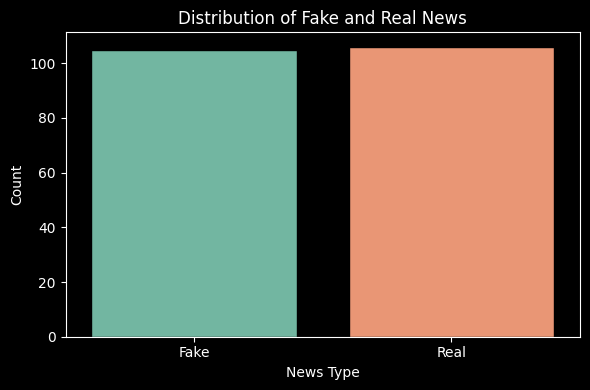

In [8]:
# Plotting the distribution of labels
plt.figure(figsize=(6, 4))
sns.countplot(x="label", hue="label", data=df, palette="Set2", legend=False, edgecolor='black')
plt.title("Distribution of Fake and Real News")
plt.xlabel("News Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

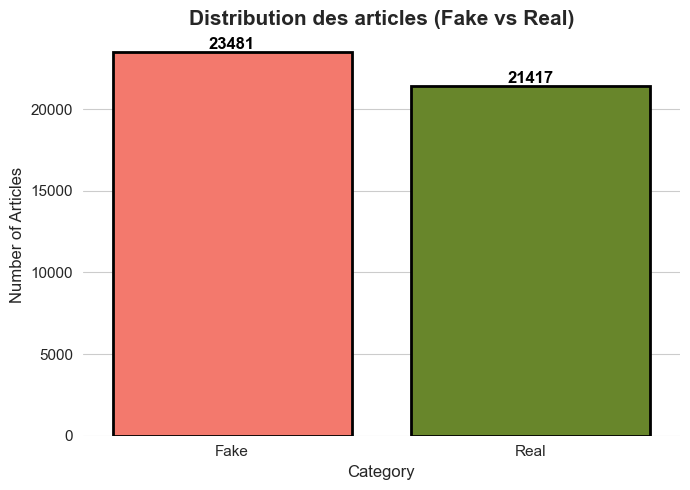

In [ ]:
# Graphique 1 : Distribution des catégories (plus esthétique)
plt.figure(figsize=(7, 5))
palette = {'Fake': '#FF6F61', 'Real': '#6B8E23'}
sns.set_style("whitegrid")
ax = sns.countplot(
    x='label',
    hue='label',
    data=df,
    palette=palette,
    edgecolor='black',
    linewidth=2,
    saturation=0.85,
    legend=False
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
plt.title('Distribution des articles (Fake vs Real)', fontsize=15, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

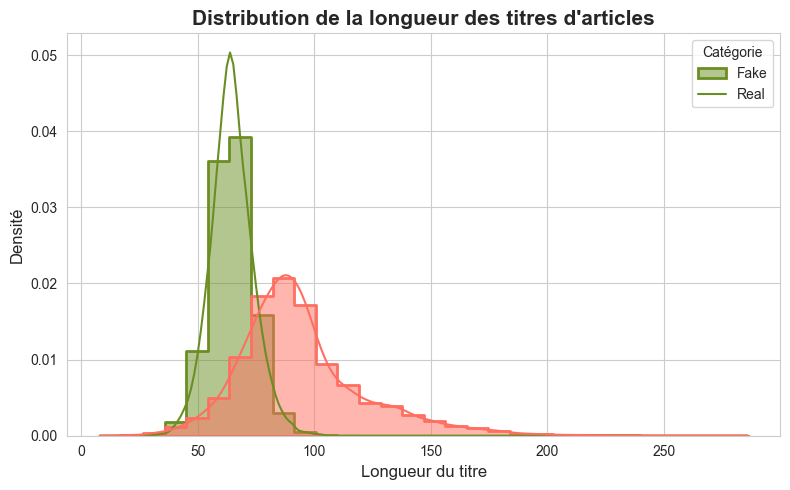

In [ ]:
# Graphique 2 : Distribution de la longueur des titres selon la catégorie

# Calculer la longueur des titres
df['title_length'] = df['title'].apply(lambda x: len(str(x)))

plt.figure(figsize=(8, 5))
palette = {'Fake': '#FF6F61', 'Real': '#6B8E23'}

# Tracer la distribution avec un histogramme
ax = sns.histplot(
    data=df,
    x='title_length',
    hue='label',
    palette=palette,
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    linewidth=2,
    alpha=0.5
)

plt.title("Distribution de la longueur des titres d'articles", fontsize=15, fontweight='bold')
plt.xlabel("Longueur du titre", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend(title="Catégorie", labels=["Fake", "Real"])
plt.tight_layout()
plt.show()

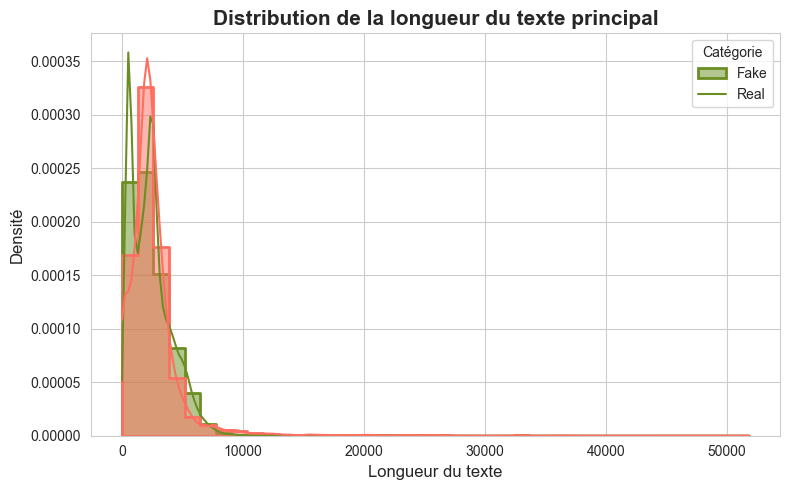

In [ ]:
# Graphique 3 : Distribution de la longueur du texte principal selon la catégorie

# Calculer la longueur du texte principal
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(8, 5))
palette = {'Fake': '#FF6F61', 'Real': '#6B8E23'}

# Tracer la distribution avec un histogramme
ax = sns.histplot(
    data=df,
    x='text_length',
    hue='label',
    palette=palette,
    bins=40,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    linewidth=2,
    alpha=0.5
)

plt.title("Distribution de la longueur du texte principal", fontsize=15, fontweight='bold')
plt.xlabel("Longueur du texte", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend(title="Catégorie", labels=["Fake", "Real"])
plt.tight_layout()
plt.show()

In [ ]:
import nltk
from collections import Counter
from wordcloud import STOPWORDS

#Télécharger les ressources NLTK
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/davidamouzou/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/davidamouzou/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords

# Définir les stopwords (anglais)
stop_words = set(stopwords.words('english')).union(STOPWORDS)

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        tokens = str(text).lower().split()
        tokens = [word.strip('.,!?;:"()[]') for word in tokens]
        tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
        words.extend(tokens)
    return Counter(words).most_common(n)

# Séparer les textes par catégorie
fake_texts = df[df['label'] == 'Fake']['text']
real_texts = df[df['label'] == 'Real']['text']

# Obtenir les 20 mots les plus fréquents pour chaque catégorie
top_fake = get_top_words(fake_texts, 20)
top_real = get_top_words(real_texts, 20)

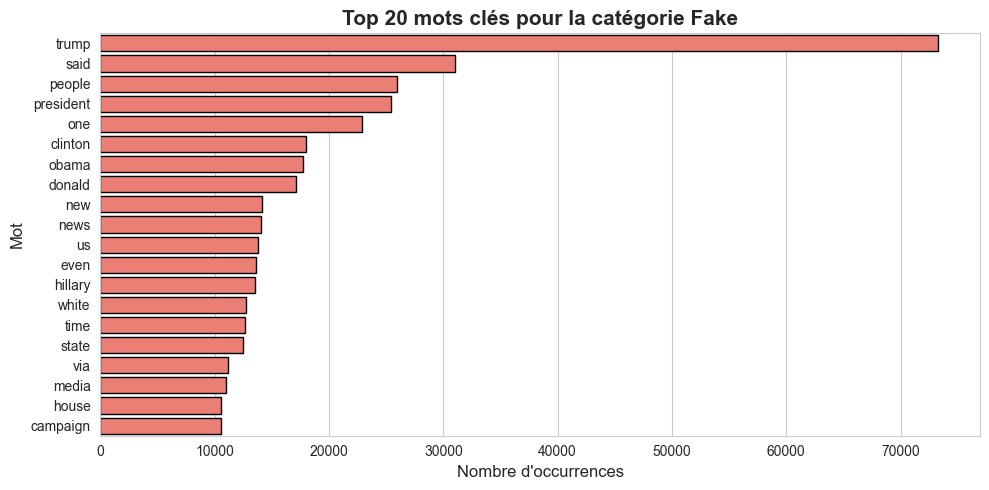

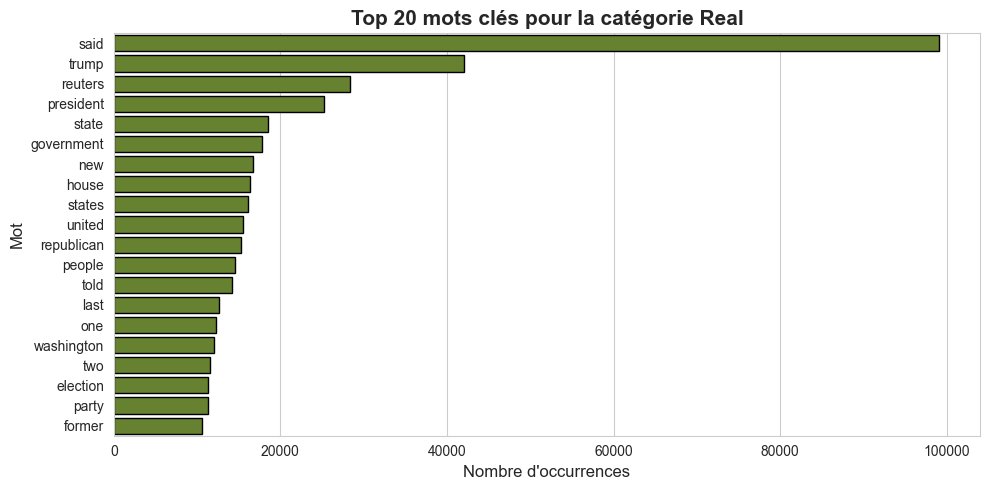

In [ ]:
# Visualisation des 20 mots clés par catégorie avec un barplot

def plot_top_keywords_by_label(top_words, label, color):
    words, counts = zip(*top_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), color=color, edgecolor='black')
    plt.title(f"Top 20 mots clés pour la catégorie {label}", fontsize=15, fontweight='bold')
    plt.xlabel("Nombre d'occurrences", fontsize=12)
    plt.ylabel("Mot", fontsize=12)
    plt.tight_layout()
    plt.show()

# Afficher pour Fake
plot_top_keywords_by_label(top_fake, "Fake", "#FF6F61")
# Afficher pour Real
plot_top_keywords_by_label(top_real, "Real", "#6B8E23")

## Préprocessing du texte

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [ ]:
def preprocess_text(text):
    """Nettoie et préprocess le texte sans dépendre de word_tokenize (évite l'erreur punkt_tab)"""
    if pd.isna(text):
        return ""
    
    # Convertir en minuscules
    text = text.lower()
    
    # Supprimer les caractères spéciaux
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenisation simple (split sur les espaces)
    tokens = text.split()
    
    # Supprimer les stop words
    stop_words = set(stopwords.words('english'))  # ou 'french'
    tokens = [token for token in tokens if token not in stop_words]
    
    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(token) for token in tokens]
    
    return ' '.join(tokens)

In [ ]:
# Appliquer le préprocessing
df['text_processed'] = df['text'].apply(preprocess_text)
df['title_processed'] = df['title'].apply(preprocess_text)

#### Caractéristiques textuelles simples

In [ ]:
from textstat import flesch_reading_ease, flesch_kincaid_grade

In [ ]:
def extract_text_features(df):
    """Extrait des caractéristiques du texte"""
    
    # Longueur du texte
    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    
    # Caractéristiques de lisibilité
    df['flesch_score'] = df['text'].apply(lambda x: flesch_reading_ease(x) if pd.notna(x) else 0)
    df['flesch_kincaid'] = df['text'].apply(lambda x: flesch_kincaid_grade(x) if pd.notna(x) else 0)
    
    # Mots en majuscules (souvent dans fake news)
    df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
    
    # Points d'exclamation et d'interrogation
    df['exclamation_count'] = df['text'].str.count('!')
    df['question_count'] = df['text'].str.count('\?')
    
    return df

df = extract_text_features(df)

In [ ]:
# sauvegarder le dataset
df.to_csv('../data/df_processed.csv', index=False)